In [1]:
pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.8/101.7 MB 9.4 MB/s eta 0:00:11
    --------------------------------------- 1.3/101.7 MB 5.0 MB/s eta 0:00:21
    --------------------------------------- 2.4/101.7 MB 4.4 MB/s eta 0:00:23
   - -------------------------------------- 3.1/101.7 MB 4.2 MB/s eta 0:00:24
   - -------------------------------------- 3.9/101.7 MB 4.2 MB/s eta 0:00:24
   - -------------------------------------- 4.7/101.7 MB 4.1 MB/s eta 0:00:24
   -- ------------------------------------- 5.5/101.7 MB 4.1 MB/s eta 0:00:24
   -- ------------------------------------- 6.3/101.7 MB 4.0 MB/s eta 0:00:24
   -- ------------------------------------- 7.1/101.7 MB 4.0 MB/s eta 0:00:24
   --- ------------------------------------ 7.9/101.7 MB 4.0 MB/s eta 0:00:24
   --- ------------------------------------ 8.7/101.7 MB 4.0 MB/s eta 0


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from xgboost import XGBClassifier

import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df =pd.read_csv("../Dataset/final_ml_dataset.csv")

In [4]:
df.drop(columns=['City'], inplace=True)

In [5]:
df_sample = df.sample( n=500000, random_state=42)

In [6]:
df_sample.shape

(500000, 13)

In [23]:
y = df_sample['Severity']
X = df_sample.drop(columns=['Severity'])

In [25]:
y = y - 1

In [26]:
print(sorted(y.unique()))

[np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


In [27]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [28]:
from xgboost import XGBClassifier
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)

In [29]:
xgb_model.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

In [30]:
y_pred = xgb_model.predict(X_test)

In [34]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)

Accuracy: 0.80077
Precision: 0.767985040355455
Recall: 0.80077
F1-Score: 0.7484305188443264


In [32]:
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.59      0.01      0.03       956
           1       0.81      0.98      0.89     78648
           2       0.61      0.18      0.28     17637
           3       0.58      0.03      0.06      2759

    accuracy                           0.80    100000
   macro avg       0.65      0.30      0.31    100000
weighted avg       0.77      0.80      0.75    100000



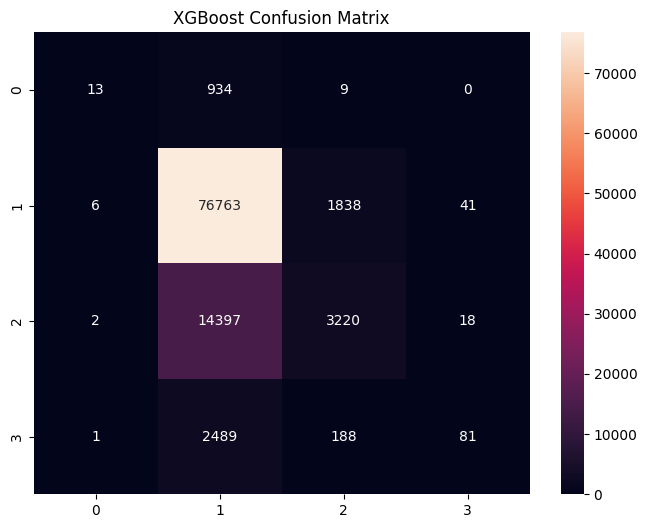

In [37]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d")
plt.title("XGBoost Confusion Matrix")
plt.savefig("../Images/xgboost_confusion_matrix.png")
plt.show()

In [39]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
})

In [40]:
importance = importance.sort_values(by="Importance", ascending=False)

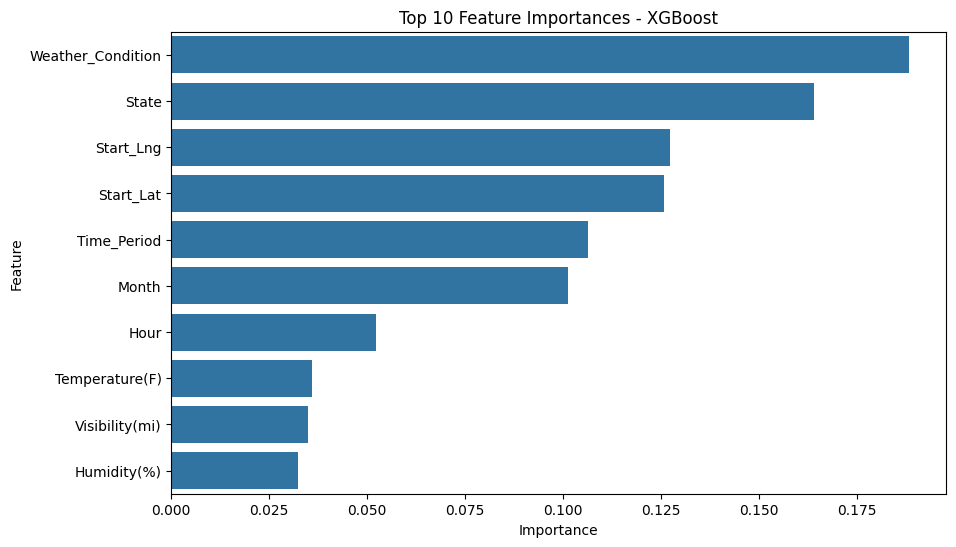

In [41]:
plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=importance.head(10))
plt.title("Top 10 Feature Importances - XGBoost")
plt.savefig("../Images/xgboost_feature_importance.png")
plt.show()

In [42]:
import joblib
joblib.dump(xgb_model, "../Python/xgboost_model.pkl")

['../Python/xgboost_model.pkl']